# 🏢 HR Intelligence System
## Machine Learning on IBM HR Analytics Dataset

| Detail | Info |
|---|---|
| **Author** | Priyal Kantharia |
| **Dataset** | IBM HR Analytics Employee Attrition |
| **Models** | 3 (Binary Classification + Multiclass Classification + Regression) |
| **Algorithm** | XGBoost with Hyperparameter Tuning |
| **Deployment** | Streamlit + Docker |

---

## 🎯 Problem Statement

HR departments face 3 critical challenges daily:

1. **Attrition** — Which employees are likely to resign? (costs $50,000+ per resignation)
2. **Job Level** — What career level does an employee belong to based on their profile?
3. **Salary** — What is the fair market salary for an employee?

This project builds **3 ML models** to solve all 3 problems from a single dataset — enabling data-driven HR decision making.

| Model | Target | Type | Metric |
|---|---|---|---|
| Model 1 | Attrition | Binary Classification | ROC-AUC |
| Model 2 | Job Level | Multiclass Classification | F1 Weighted |
| Model 3 | Monthly Income | Regression | R² Score |

## 📦 Step 1 — Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              r2_score, mean_absolute_error,
                              confusion_matrix, classification_report,
                              RocCurveDisplay)
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 📂 Step 2 — Load Dataset

In [9]:
df = pd.read_csv('C:\\Users\\Priyal Kantharia\\Desktop\\ALL projects\\Employee performance Analysis\\data\\WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop columns with single unique value — no predictive power
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

print(f'Dataset Shape: {df.shape}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')
df.head()

Dataset Shape: (1470, 31)
Missing Values: 0
Duplicate Rows: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

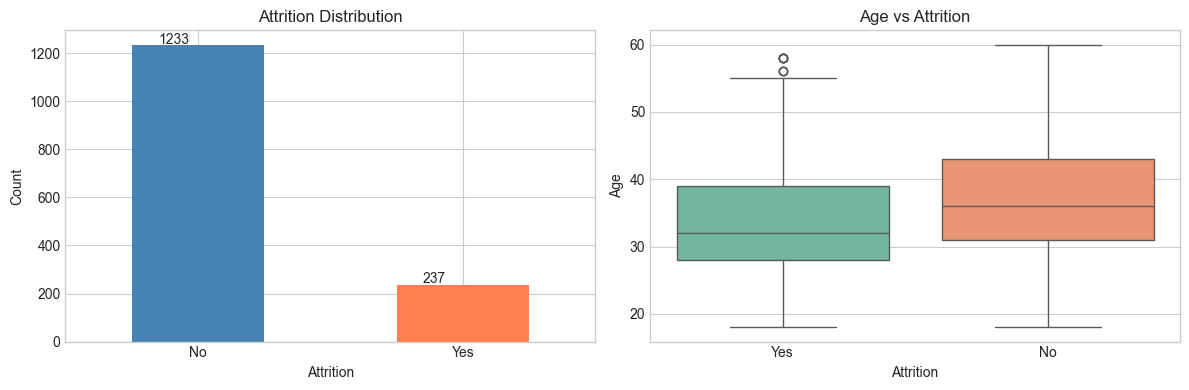


Attrition Rate: 16.1%


In [12]:
# Attrition distribution + Age vs Attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Attrition'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Attrition Distribution')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x()+0.1, p.get_height()+5))

sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age vs Attrition')

plt.tight_layout()
plt.show()
print(f'\nAttrition Rate: {df["Attrition"].value_counts(normalize=True)["Yes"]*100:.1f}%')

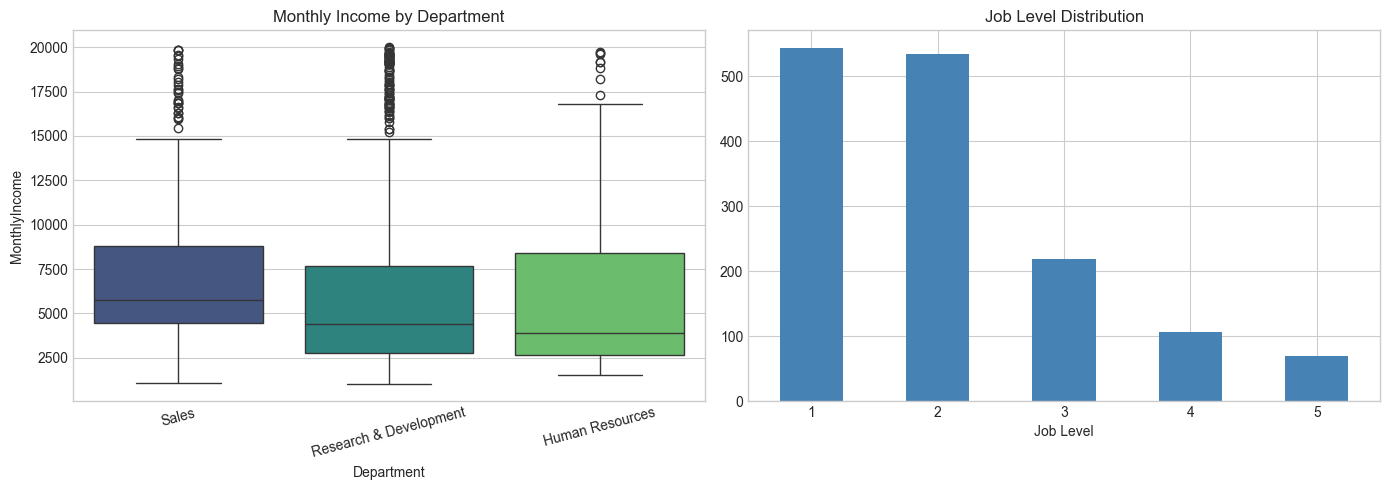

In [13]:
# Salary by Department + Job Level Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Department', y='MonthlyIncome', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Monthly Income by Department')
axes[0].tick_params(axis='x', rotation=15)

df['JobLevel'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Job Level Distribution')
axes[1].set_xlabel('Job Level')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

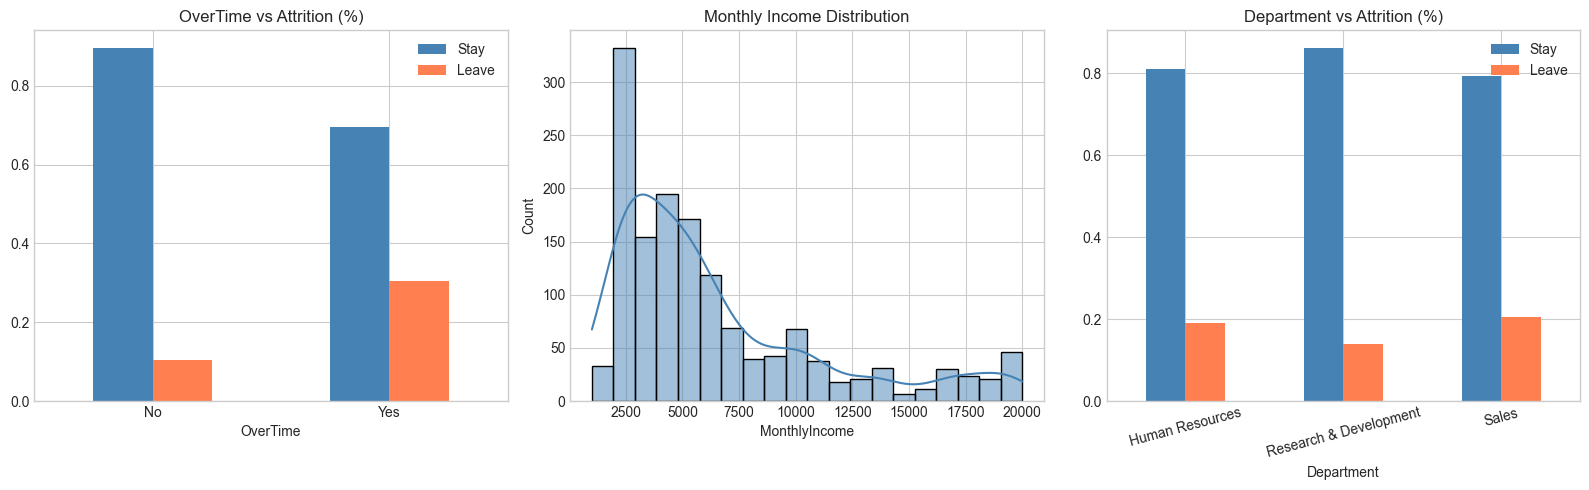

In [14]:
# Overtime vs Attrition + Income Distribution + Department vs Attrition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('OverTime vs Attrition (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Stay', 'Leave'])

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Income Distribution')

pd.crosstab(df['Department'], df['Attrition'], normalize='index').plot(
    kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_title('Department vs Attrition (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(['Stay', 'Leave'])

plt.tight_layout()
plt.show()

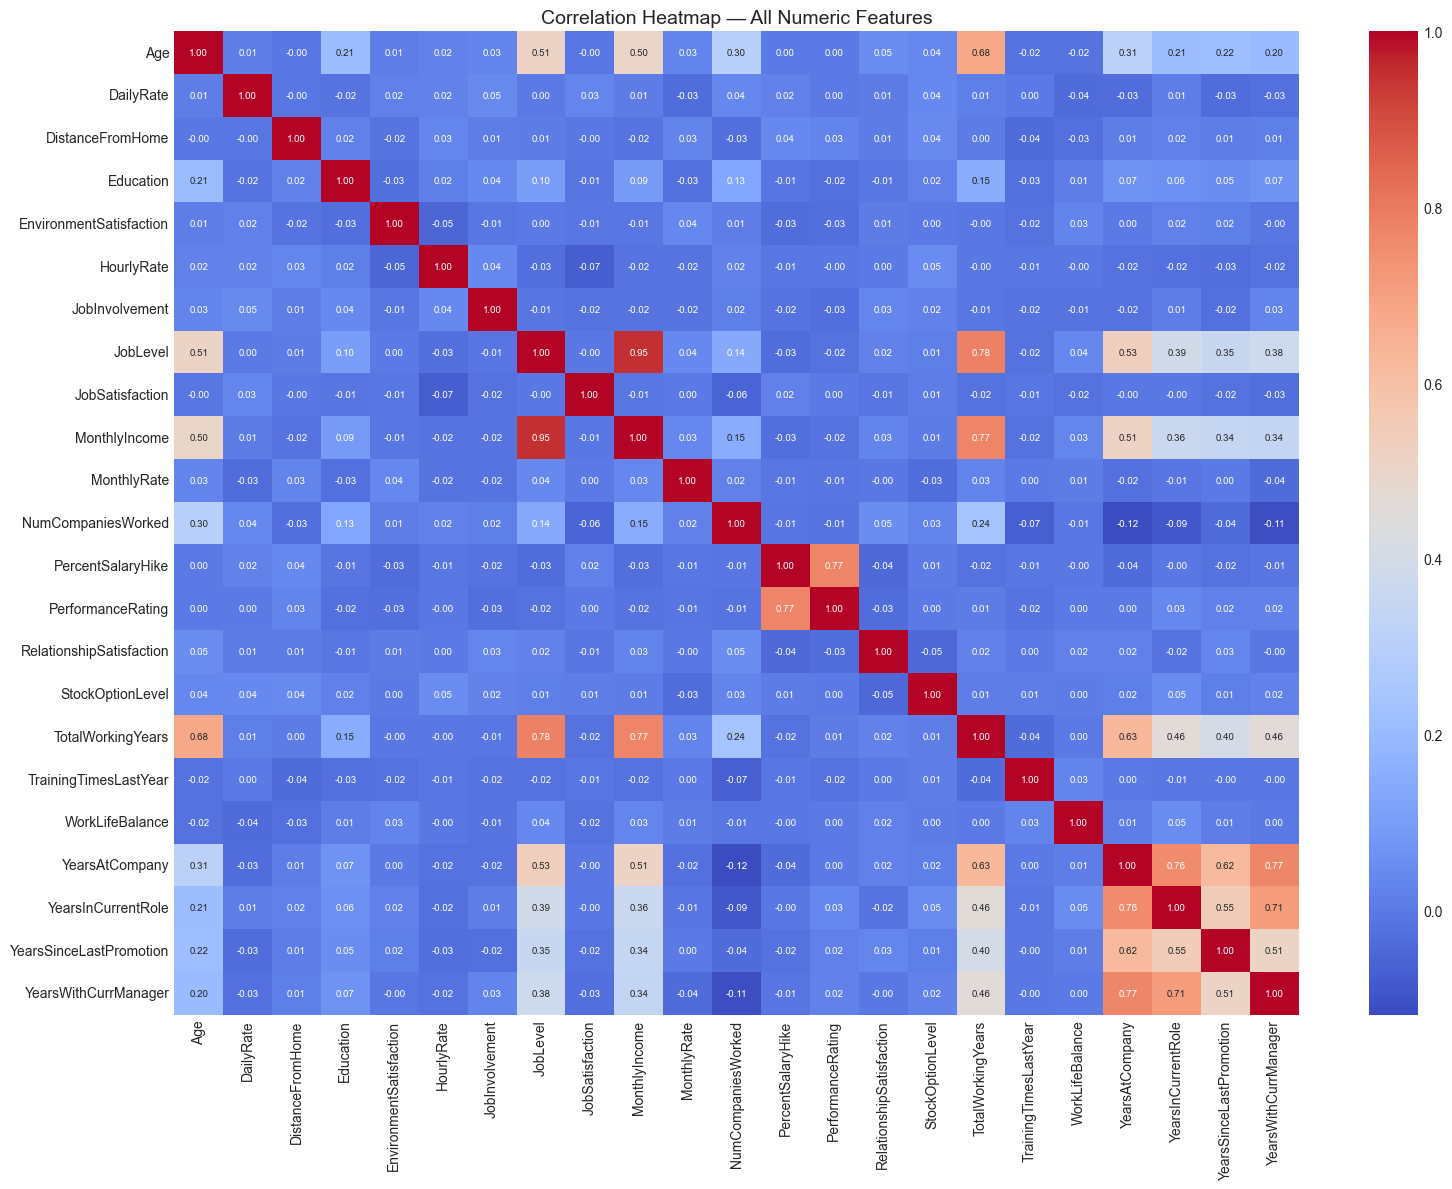

In [15]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

## 🛠️ Step 4 — Data Preprocessing & Feature Engineering

In [16]:
# Encode binary/ordinal columns
df['Attrition_encoded'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime_encoded']  = (df['OverTime'] == 'Yes').astype(int)
df['Gender_encoded']    = (df['Gender'] == 'Male').astype(int)
df['JobLevel_encoded']  = df['JobLevel'] - 1  # 1-5 → 0-4 for XGBoost

# Define feature groups
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

base_num = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education',
    'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
    'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'OverTime_encoded', 'Gender_encoded'
]

# Each model has different features to avoid leakage
num_m1 = base_num + ['MonthlyIncome', 'JobLevel']   # Attrition
num_m2 = base_num + ['MonthlyIncome']                # Job Level (target = JobLevel)
num_m3 = base_num + ['JobLevel']                     # Salary (target = MonthlyIncome)

print('Feature Engineering Complete ✅')
print(f'Model 1 (Attrition) features:  {len(num_m1)} numeric + {len(cat_features)} categorical')
print(f'Model 2 (Job Level) features:  {len(num_m2)} numeric + {len(cat_features)} categorical')
print(f'Model 3 (Salary) features:     {len(num_m3)} numeric + {len(cat_features)} categorical')

Feature Engineering Complete ✅
Model 1 (Attrition) features:  25 numeric + 5 categorical
Model 2 (Job Level) features:  24 numeric + 5 categorical
Model 3 (Salary) features:     24 numeric + 5 categorical


---
# 🚨 MODEL 1 — Employee Attrition Predictor
**Question:** Will this employee resign?

**Type:** Binary Classification (Yes / No)

**Challenge:** Class imbalance — only 16% employees resigned → using SMOTE

In [17]:
# Class imbalance check
print('Attrition Class Distribution:')
print(df['Attrition'].value_counts())
print(f'\nImbalance Ratio: {df["Attrition"].value_counts()["No"]/df["Attrition"].value_counts()["Yes"]:.1f}:1')

Attrition Class Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Imbalance Ratio: 5.2:1


In [18]:
# Train-Test Split (stratified to maintain class ratio)
X1 = df[num_m1 + cat_features]
y1 = df['Attrition_encoded']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)

print(f'Train: {X1_train.shape} | Test: {X1_test.shape}')
print(f'Train class ratio: {y1_train.value_counts().to_dict()}')
print(f'Test class ratio:  {y1_test.value_counts().to_dict()}')

Train: (1176, 30) | Test: (294, 30)
Train class ratio: {0: 986, 1: 190}
Test class ratio:  {0: 247, 1: 47}


In [19]:
# Preprocessor
pre1 = ColumnTransformer([
    ('num', StandardScaler(), num_m1),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# Model Comparison (with SMOTE)
m1_results = []
for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss'))
]:
    pipe = ImbPipeline([
        ('pre', pre1), ('smote', SMOTE(random_state=42)), ('model', model)
    ])
    pipe.fit(X1_train, y1_train)
    yp  = pipe.predict(X1_test)
    ypr = pipe.predict_proba(X1_test)[:,1]
    m1_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y1_test, yp), 4),
        'F1': round(f1_score(y1_test, yp), 4),
        'ROC-AUC': round(roc_auc_score(y1_test, ypr), 4)
    })

m1_df = pd.DataFrame(m1_results)
print('Model 1 — Comparison Results:')
print(m1_df.to_string(index=False))

Model 1 — Comparison Results:
              Model  Accuracy     F1  ROC-AUC
Logistic Regression    0.7755 0.4762   0.7992
      Random Forest    0.8571 0.3000   0.7808
            XGBoost    0.8741 0.4478   0.7710


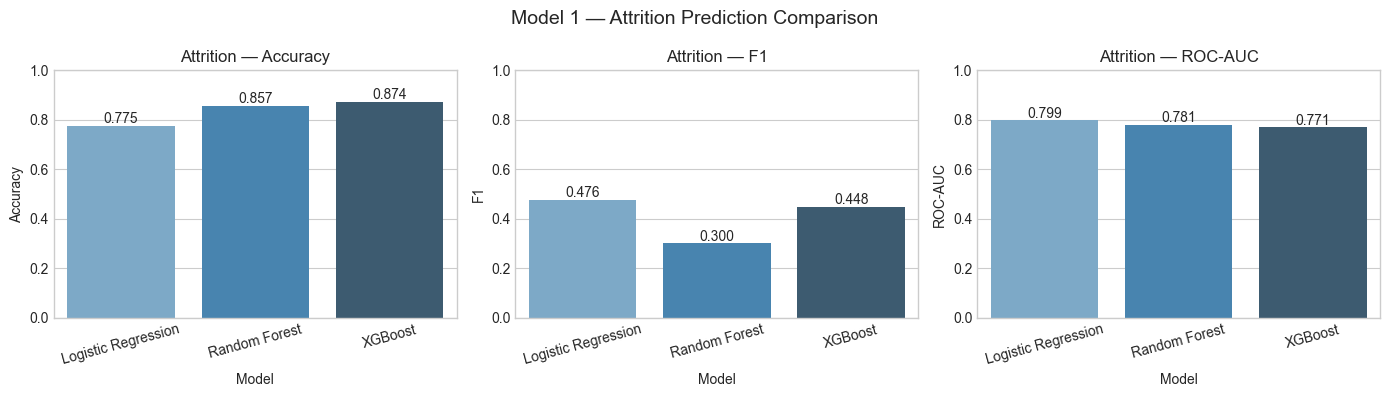

In [20]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(['Accuracy', 'F1', 'ROC-AUC']):
    sns.barplot(x='Model', y=metric, data=m1_df, ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Attrition — {metric}')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}',
                         (p.get_x()+p.get_width()/2, p.get_height()+0.01), ha='center')
plt.suptitle('Model 1 — Attrition Prediction Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Hyperparameter Tuning — XGBoost
xgb1 = ImbPipeline([
    ('pre', pre1),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

params1 = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 5],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample':     [0.8, 1.0]
}

search1 = RandomizedSearchCV(
    xgb1, params1, n_iter=10, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
search1.fit(X1_train, y1_train)

print(f'Best Parameters: {search1.best_params_}')
print(f'Best CV ROC-AUC: {search1.best_score_:.4f}')

Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best CV ROC-AUC: 0.8194


In [22]:
# Cross Validation
best1 = search1.best_estimator_
cv1 = cross_val_score(best1, X1, y1, cv=5, scoring='roc_auc')
print('5-Fold Cross Validation — ROC-AUC:')
print(f'Scores: {cv1.round(4)}')
print(f'Mean:   {cv1.mean():.4f}')
print(f'Std:    {cv1.std():.4f}')

5-Fold Cross Validation — ROC-AUC:
Scores: [0.8294 0.7928 0.8315 0.7923 0.853 ]
Mean:   0.8198
Std:    0.0238


In [23]:
# Final Evaluation
y1p  = best1.predict(X1_test)
y1pr = best1.predict_proba(X1_test)[:,1]

print('=== FINAL ATTRITION MODEL RESULTS ===')
print(f'Accuracy:  {accuracy_score(y1_test, y1p):.4f}')
print(f'F1 Score:  {f1_score(y1_test, y1p):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y1_test, y1pr):.4f}')
print(f'CV ROC-AUC: {cv1.mean():.4f} +/- {cv1.std():.4f}')
print()
print(classification_report(y1_test, y1p, target_names=['Stay', 'Leave']))

=== FINAL ATTRITION MODEL RESULTS ===
Accuracy:  0.8673
F1 Score:  0.4179
ROC-AUC:   0.7705
CV ROC-AUC: 0.8198 +/- 0.0238

              precision    recall  f1-score   support

        Stay       0.88      0.98      0.93       247
       Leave       0.70      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.79      0.64      0.67       294
weighted avg       0.85      0.87      0.84       294



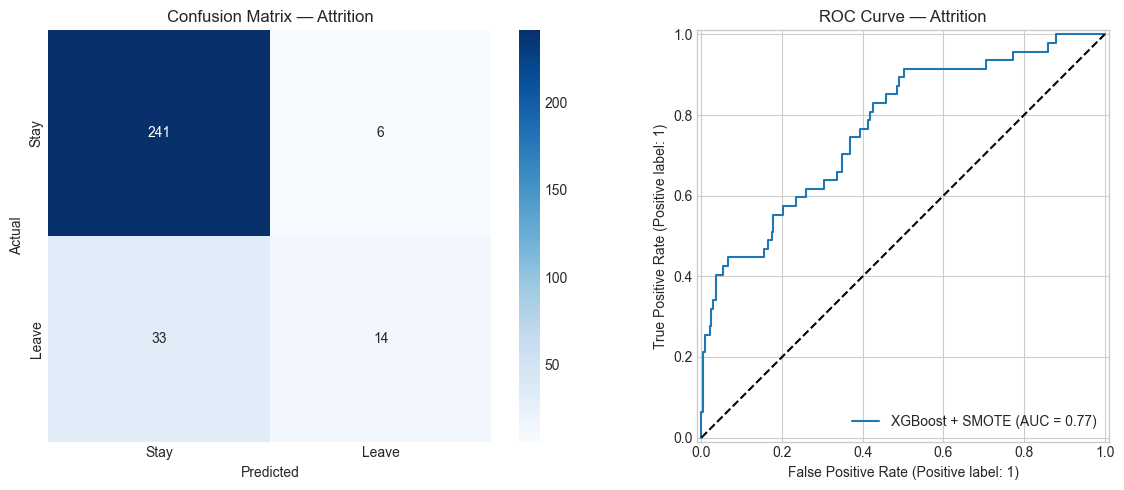

In [24]:
# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y1_test, y1p)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'])
axes[0].set_title('Confusion Matrix — Attrition')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y1_test, y1pr, ax=axes[1], name='XGBoost + SMOTE')
axes[1].set_title('ROC Curve — Attrition')
axes[1].plot([0,1],[0,1],'k--', label='Random Classifier')

plt.tight_layout()
plt.show()

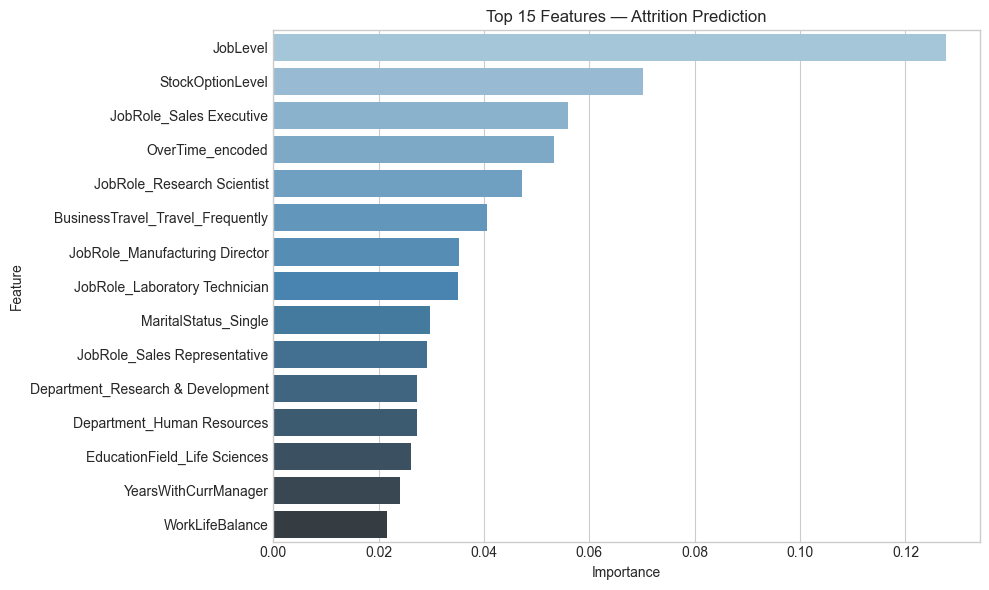

In [25]:
# Feature Importance — Model 1
fi1_names = (num_m1 +
             best1.named_steps['pre'].named_transformers_['cat']
             .get_feature_names_out(cat_features).tolist())
fi1_vals  = best1.named_steps['model'].feature_importances_
fi1_df    = pd.DataFrame({'Feature': fi1_names, 'Importance': fi1_vals})
fi1_df    = fi1_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi1_df, palette='Blues_d')
plt.title('Top 15 Features — Attrition Prediction')
plt.tight_layout()
plt.show()

In [26]:
joblib.dump(best1, 'attrition_model.pkl')
print('Attrition model saved ✅')

Attrition model saved ✅


---
# 🏢 MODEL 2 — Job Level Predictor
**Question:** What career level does this employee belong to?

**Type:** Multiclass Classification (Entry / Mid / Senior / Lead / Director)

**Note:** JobLevel strongly correlates with experience and income — highly predictable

In [27]:
print('Job Level Distribution:')
labels = {1:'Entry',2:'Mid',3:'Senior',4:'Lead',5:'Director'}
print(df['JobLevel'].map(labels).value_counts())

Job Level Distribution:
JobLevel
Entry       543
Mid         534
Senior      218
Lead        106
Director     69
Name: count, dtype: int64


In [28]:
X2 = df[num_m2 + cat_features]
y2 = df['JobLevel_encoded']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f'Train: {X2_train.shape} | Test: {X2_test.shape}')

Train: (1176, 29) | Test: (294, 29)


In [29]:
pre2 = ColumnTransformer([
    ('num', StandardScaler(), num_m2),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

m2_results = []
for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='mlogloss'))
]:
    pipe = Pipeline([('pre', pre2), ('model', model)])
    pipe.fit(X2_train, y2_train)
    yp = pipe.predict(X2_test)
    m2_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y2_test, yp), 4),
        'F1 Weighted': round(f1_score(y2_test, yp, average='weighted'), 4)
    })

m2_df = pd.DataFrame(m2_results)
print('Model 2 — Comparison Results:')
print(m2_df.to_string(index=False))

Model 2 — Comparison Results:
              Model  Accuracy  F1 Weighted
Logistic Regression    0.8469       0.8438
      Random Forest    0.8946       0.8935
            XGBoost    0.9354       0.9355


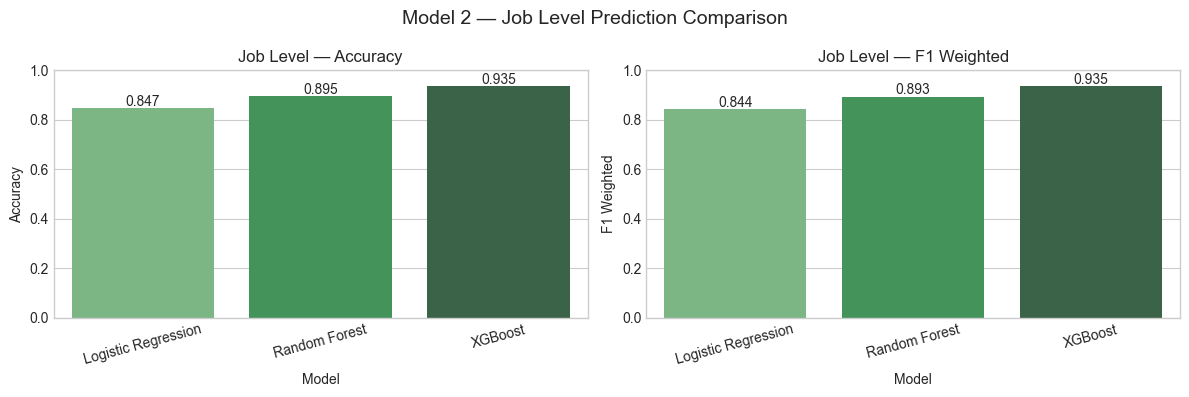

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(['Accuracy', 'F1 Weighted']):
    sns.barplot(x='Model', y=metric, data=m2_df, ax=axes[i], palette='Greens_d')
    axes[i].set_title(f'Job Level — {metric}')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}',
                         (p.get_x()+p.get_width()/2, p.get_height()+0.01), ha='center')
plt.suptitle('Model 2 — Job Level Prediction Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
xgb2 = Pipeline([
    ('pre', pre2),
    ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

params2 = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample':     [0.8, 1.0]
}

search2 = RandomizedSearchCV(
    xgb2, params2, n_iter=10, cv=5,
    scoring='f1_weighted', random_state=42, n_jobs=-1, verbose=0)
search2.fit(X2_train, y2_train)

print(f'Best Parameters: {search2.best_params_}')
print(f'Best CV F1:      {search2.best_score_:.4f}')

Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.01}
Best CV F1:      0.9362


In [32]:
best2 = search2.best_estimator_
cv2   = cross_val_score(best2, X2, y2, cv=5, scoring='f1_weighted')
print('5-Fold Cross Validation — F1 Weighted:')
print(f'Scores: {cv2.round(4)}')
print(f'Mean:   {cv2.mean():.4f}')
print(f'Std:    {cv2.std():.4f}')

5-Fold Cross Validation — F1 Weighted:
Scores: [0.9453 0.9355 0.949  0.9557 0.9251]
Mean:   0.9421
Std:    0.0107


In [33]:
y2p = best2.predict(X2_test)

print('=== FINAL JOB LEVEL MODEL RESULTS ===')
print(f'Accuracy:    {accuracy_score(y2_test, y2p):.4f}')
print(f'F1 Weighted: {f1_score(y2_test, y2p, average="weighted"):.4f}')
print(f'CV F1:       {cv2.mean():.4f} +/- {cv2.std():.4f}')
print()
print(classification_report(y2_test, y2p,
      target_names=['Entry','Mid','Senior','Lead','Director']))

=== FINAL JOB LEVEL MODEL RESULTS ===
Accuracy:    0.9354
F1 Weighted: 0.9352
CV F1:       0.9421 +/- 0.0107

              precision    recall  f1-score   support

       Entry       0.93      0.94      0.94       109
         Mid       0.92      0.90      0.91       107
      Senior       0.93      0.95      0.94        43
        Lead       1.00      1.00      1.00        21
    Director       1.00      1.00      1.00        14

    accuracy                           0.94       294
   macro avg       0.96      0.96      0.96       294
weighted avg       0.94      0.94      0.94       294



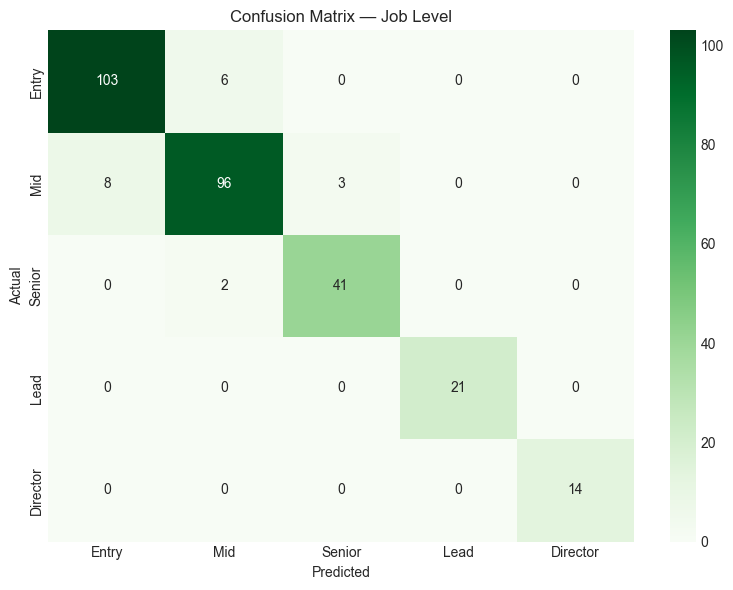

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
cm2 = confusion_matrix(y2_test, y2p)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Entry','Mid','Senior','Lead','Director'],
            yticklabels=['Entry','Mid','Senior','Lead','Director'])
ax.set_title('Confusion Matrix — Job Level')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

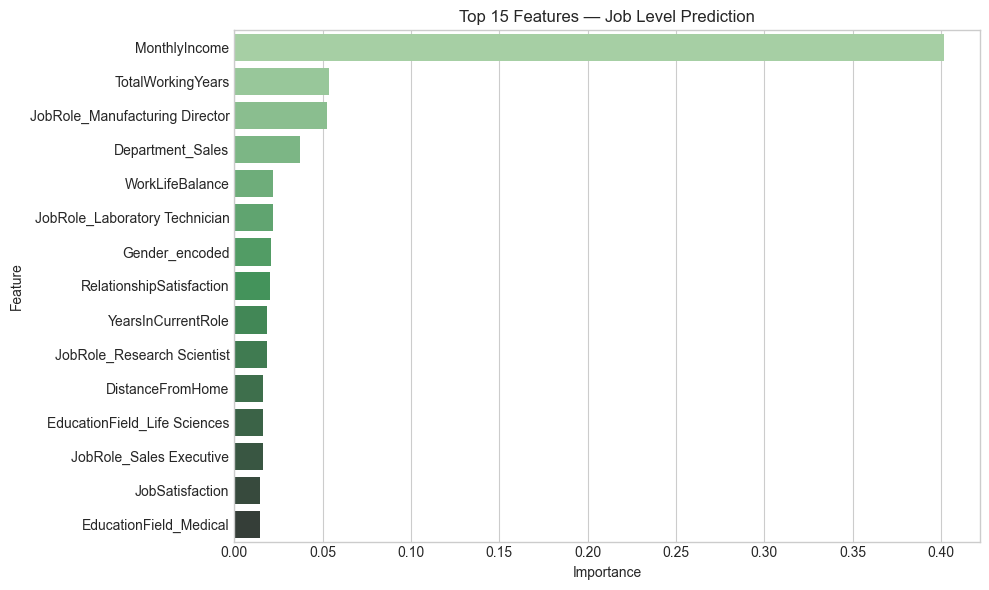

In [35]:
fi2_names = (num_m2 +
             best2.named_steps['pre'].named_transformers_['cat']
             .get_feature_names_out(cat_features).tolist())
fi2_vals  = best2.named_steps['model'].feature_importances_
fi2_df    = pd.DataFrame({'Feature': fi2_names, 'Importance': fi2_vals})
fi2_df    = fi2_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi2_df, palette='Greens_d')
plt.title('Top 15 Features — Job Level Prediction')
plt.tight_layout()
plt.show()

In [36]:
joblib.dump(best2, 'joblevel_model.pkl')
print('Job Level model saved ✅')

Job Level model saved ✅


---
# 💰 MODEL 3 — Monthly Income Predictor
**Question:** What is the fair market salary for this employee?

**Type:** Regression (continuous value prediction)

**Note:** Salary strongly depends on Job Level, experience, and role

Monthly Income Stats:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


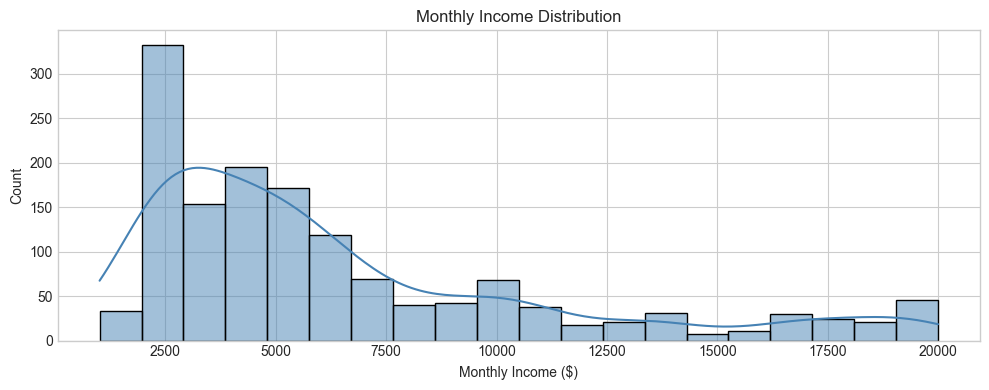

In [37]:
print('Monthly Income Stats:')
print(df['MonthlyIncome'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['MonthlyIncome'], kde=True, color='steelblue')
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income ($)')
plt.tight_layout()
plt.show()

In [38]:
X3 = df[num_m3 + cat_features]
y3 = df['MonthlyIncome']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42)

print(f'Train: {X3_train.shape} | Test: {X3_test.shape}')

Train: (1176, 29) | Test: (294, 29)


In [39]:
pre3 = ColumnTransformer([
    ('num', StandardScaler(), num_m3),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

m3_results = []
for name, model in [
    ('Ridge', Ridge()),
    ('Random Forest', RandomForestRegressor(random_state=42, n_estimators=100)),
    ('XGBoost', XGBRegressor(random_state=42))
]:
    pipe = Pipeline([('pre', pre3), ('model', model)])
    pipe.fit(X3_train, y3_train)
    yp = pipe.predict(X3_test)
    m3_results.append({
        'Model': name,
        'R2 Score': round(r2_score(y3_test, yp), 4),
        'MAE ($)': round(mean_absolute_error(y3_test, yp), 0)
    })

m3_df = pd.DataFrame(m3_results)
print('Model 3 — Comparison Results:')
print(m3_df.to_string(index=False))

Model 3 — Comparison Results:
        Model  R2 Score  MAE ($)
        Ridge    0.9374    892.0
Random Forest    0.9440    825.0
      XGBoost    0.9371    878.0


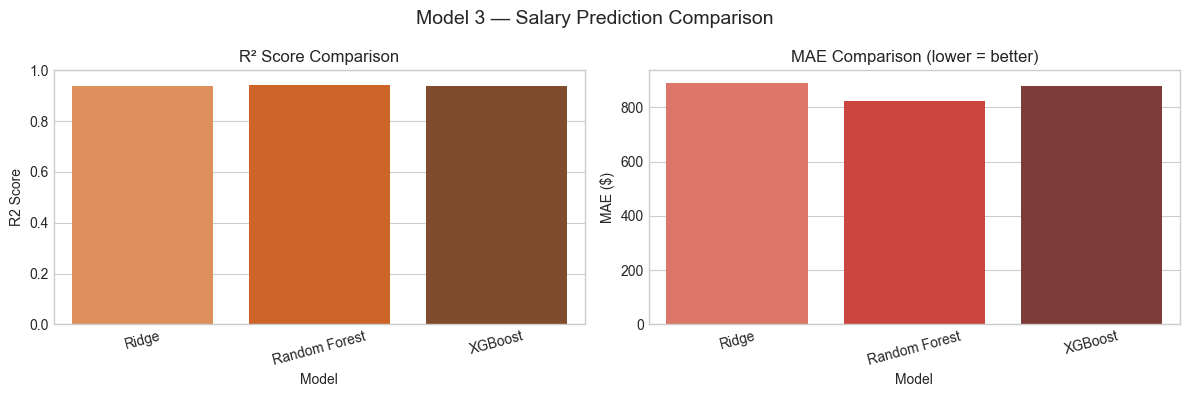

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Model', y='R2 Score', data=m3_df, ax=axes[0], palette='Oranges_d')
axes[0].set_title('R² Score Comparison')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(x='Model', y='MAE ($)', data=m3_df, ax=axes[1], palette='Reds_d')
axes[1].set_title('MAE Comparison (lower = better)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model 3 — Salary Prediction Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
xgb3 = Pipeline([
    ('pre', pre3),
    ('model', XGBRegressor(random_state=42))
])

params3 = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

search3 = RandomizedSearchCV(
    xgb3, params3, n_iter=10, cv=5,
    scoring='r2', random_state=42, n_jobs=-1, verbose=0)
search3.fit(X3_train, y3_train)

print(f'Best Parameters: {search3.best_params_}')
print(f'Best CV R²:      {search3.best_score_:.4f}')

Best Parameters: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best CV R²:      0.9515


In [42]:
best3 = search3.best_estimator_
cv3   = cross_val_score(best3, X3, y3, cv=5, scoring='r2')
print('5-Fold Cross Validation — R²:')
print(f'Scores: {cv3.round(4)}')
print(f'Mean:   {cv3.mean():.4f}')
print(f'Std:    {cv3.std():.4f}')

5-Fold Cross Validation — R²:
Scores: [0.956  0.9488 0.9562 0.9547 0.9356]
Mean:   0.9502
Std:    0.0078


In [43]:
y3p = best3.predict(X3_test)

print('=== FINAL SALARY MODEL RESULTS ===')
print(f'R² Score: {r2_score(y3_test, y3p):.4f}')
print(f'MAE:      ${mean_absolute_error(y3_test, y3p):.0f}')
print(f'CV R²:    {cv3.mean():.4f} +/- {cv3.std():.4f}')

=== FINAL SALARY MODEL RESULTS ===
R² Score: 0.9447
MAE:      $810
CV R²:    0.9502 +/- 0.0078


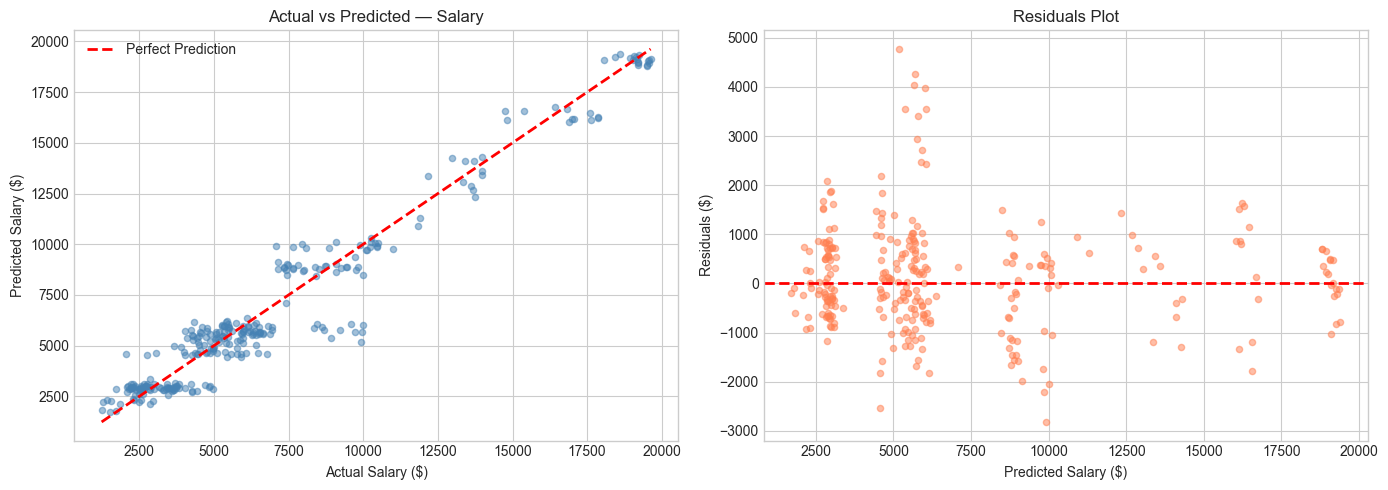

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y3_test, y3p, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y3_test.min(), y3_test.max()],
             [y3_test.min(), y3_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Salary ($)')
axes[0].set_ylabel('Predicted Salary ($)')
axes[0].set_title('Actual vs Predicted — Salary')
axes[0].legend()

residuals = y3_test - y3p
axes[1].scatter(y3p, residuals, alpha=0.5, color='coral', s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

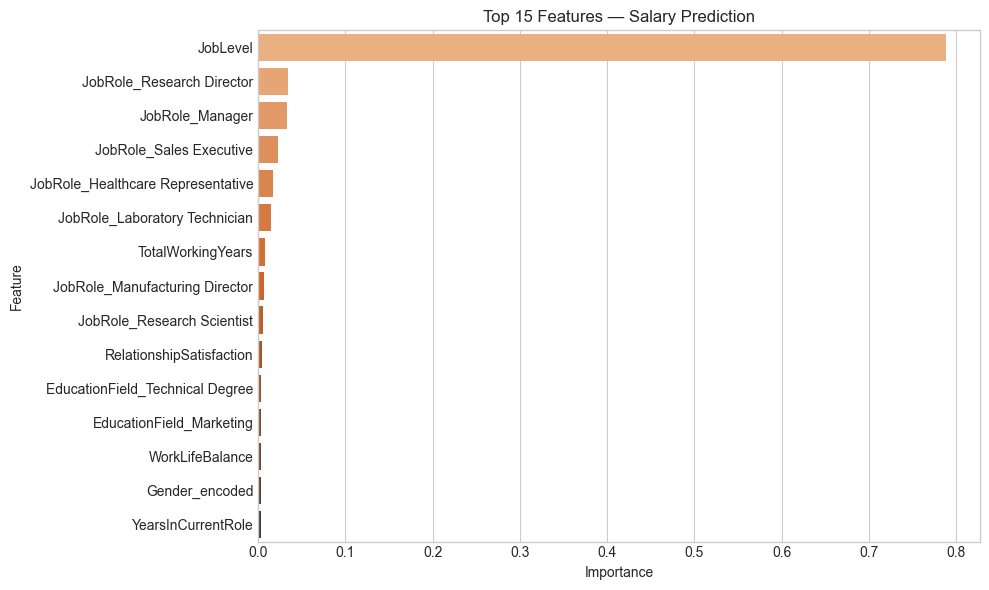

In [45]:
fi3_names = (num_m3 +
             best3.named_steps['pre'].named_transformers_['cat']
             .get_feature_names_out(cat_features).tolist())
fi3_vals  = best3.named_steps['model'].feature_importances_
fi3_df    = pd.DataFrame({'Feature': fi3_names, 'Importance': fi3_vals})
fi3_df    = fi3_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi3_df, palette='Oranges_d')
plt.title('Top 15 Features — Salary Prediction')
plt.tight_layout()
plt.show()

In [46]:
joblib.dump(best3, 'salary_model.pkl')
print('Salary model saved ✅')

Salary model saved ✅


## ✅ Final Summary

In [47]:
print('=' * 55)
print('        HR INTELLIGENCE SYSTEM — FINAL RESULTS')
print('=' * 55)
print(f'{'Model':<30} {'Metric':<15} {'Score'}')
print('-' * 55)
print(f'{'Attrition Predictor':<30} {'CV ROC-AUC':<15} {cv1.mean():.4f}')
print(f'{'Job Level Predictor':<30} {'CV F1':<15} {cv2.mean():.4f}')
print(f'{'Salary Predictor':<30} {'CV R2':<15} {cv3.mean():.4f}')
print('=' * 55)
print()
print('Models saved:')
print('  attrition_model.pkl ✅')
print('  joblevel_model.pkl  ✅')
print('  salary_model.pkl    ✅')
print()
print('Tech Stack:')
print('  Python | Pandas | XGBoost | SMOTE')
print('  Scikit-learn | Streamlit | Docker')
print()
print('Author: Priyal Kantharia')

        HR INTELLIGENCE SYSTEM — FINAL RESULTS
Model                          Metric          Score
-------------------------------------------------------
Attrition Predictor            CV ROC-AUC      0.8198
Job Level Predictor            CV F1           0.9421
Salary Predictor               CV R2           0.9502

Models saved:
  attrition_model.pkl ✅
  joblevel_model.pkl  ✅
  salary_model.pkl    ✅

Tech Stack:
  Python | Pandas | XGBoost | SMOTE
  Scikit-learn | Streamlit | Docker

Author: Priyal Kantharia
